# Trading Game #1 — Optimal Market-Neutral Multivariate Pair Trading - Rice commodity

**GAUSSIN Natacha**
**FOURREAU Mathis**

*ESILV IF3 - Commodities Markets and Models*
 
**Reference:** Yang, H., & Malik, A. (2024). *Optimal market-neutral multivariate pair trading on the cryptocurrency platform.* International Journal of Financial Studies, 12(3), 77.  
**GitHub (original code):** https://github.com/Hongshen-Yang/optimal-trading-technique

---

### Objective

The aim of this notebook is to replicate and adapt the **Optimal Trading Technique (OTT)** developend in the reference article written by Yang & Malik (2024) to the **rice commodity sector**.  
The original paper applies OTT to cryptocurrency/fiat currency pairs. Here, we adapt the approach: instead of a cryptocurrency as the anchor, we use the **Rice Futures contract** as the primary anchor, and a selection of rice-related equities as the trading universe.

### Key Adaptation from the Paper

| Original (Yang & Malik 2024) | This Notebook |
|---|---|
| Anchor: ETH (cryptocurrency) | Anchor: Rice Futures |
| Fiat currencies: USD, CAD, GBP, EUR | Equities: KRBL.NS, ADM, BG, DBA, AGRO (rice-related stocks) ...|
| Data: minute-frequency OHLCVT from Kraken | Data: daily OHLCV from Yahoo Finance / Bloomberg |
| Optimization: Gurobi (bi-objective) | Optimization: Gurobi (same formulation) |

### Notebook Structure

1. Setup & Data Loading
2. Data Cleaning & Exploration
3. Asset Screening (Correlation + Cointegration)
4. Spread Computation & Z-Score Signaling
5. Historical Analysis (Expected Returns & Risk)
6. Optimal Trading (Gurobi Optimization)
7. Simulation & Backtesting
8. Performance Evaluation (OTT vs Buy-and-Hold)
9. Conclusion

---
## 1. Setup & Data Loading

In [24]:
# =============================================================================
# IMPORTS
# =============================================================================
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import linregress
from statsmodels.tsa.stattools import adfuller
import gurobipy as gp
from gurobipy import GRB

# Display settings
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 20)
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print("All libraries imported successfully.")

All libraries imported successfully.


**Global parameters**

We define parameters that will be useful throughout the code :

First we define **trading thresholds** in units of standard deviation:
- `OPEN_THRESHOLD` represents how many standard deviations the z-score must exceed to open a position
- `CLOSE_THRESHOLD` represents how many standard deviations the z-score must fall below to close a position

Then we define the risk aversion parameter,`LAMBDA` = $\lambda$, that controls the trade-off between the return and risk in the Gurobi optimization. We set this parameter to the default value $1$. A higher value would be more conservative and a lower value would be more aggresive.

We set the transaction cost parameter `TX_COST` to 0.001, namely 10Bps, as indicated in the project guidelines. 

The initial capital per asset, `ORIG_AMOUNT`, at the start is set at 10 000 USD. 

The risk free rate, `RISK_FREE_RATE`, is set at 4%.

In [2]:
# =============================
# GLOBAL PARAMETERS
# =============================

OPEN_THRESHOLD  = 2.0   # open position when |z-score| > OPEN_THRESHOLD * std
CLOSE_THRESHOLD = 1.0   # close position when |z-score| < CLOSE_THRESHOLD * std
LAMBDA = 1.0 # risk aversion paramter
TX_COST = 0.001   # 0.1% per trade (10 basis points)
ORIG_AMOUNT = 10_000   # USD 10,000 per asset at the start
RISK_FREE_RATE = 0.04  # 4% annual (approximation of US 10-Year Treasury)

# --- Data split ---
# Formation period: used to compute thresholds, correlations, cointegration
# Trading period:  out-of-sample, used for backtesting
FORMATION_START = '2020-01-01'
FORMATION_END   = '2022-12-31'
TRADING_START   = '2023-01-01'
TRADING_END     = '2026-03-06'   # last available date in dataset

print("Global parameters set.")
print(f"  Formation period : {FORMATION_START} → {FORMATION_END}")
print(f"  Trading period   : {TRADING_START} → {TRADING_END}")
print(f"  Open threshold   : {OPEN_THRESHOLD} sigma")
print(f"  Close threshold  : {CLOSE_THRESHOLD} sigma")
print(f"  Lambda (risk)    : {LAMBDA}")
print(f"  Transaction cost : {TX_COST*100:.1f} bps")

Global parameters set.
  Formation period : 2020-01-01 → 2022-12-31
  Trading period   : 2023-01-01 → 2026-03-06
  Open threshold   : 2.0 sigma
  Close threshold  : 1.0 sigma
  Lambda (risk)    : 1.0
  Transaction cost : 0.1 bps


In [3]:
# =============================================================================
# DATA LOADING
# =============================================================================
# Upload the dataset before running this cell.
# If running on Google Colab, uncomment the next lines:
# from google.colab import files
# uploaded = files.upload()   # select data.csv

# Load the CSV file
df_raw = pd.read_csv('data.csv', index_col='Date', parse_dates=True)

print(f"Dataset shape: {df_raw.shape}  ({df_raw.shape[0]} trading days, {df_raw.shape[1]} assets)")
print(f"Date range: {df_raw.index.min().date()} → {df_raw.index.max().date()}")
print()
print("Columns (assets):")
print(list(df_raw.columns))
print()
print("Missing values per asset:")
print(df_raw.isnull().sum())

Dataset shape: (2143, 16)  (2143 trading days, 16 assets)
Date range: 2018-01-01 → 2026-03-13

Columns (assets):
['1688.T', 'ADM', 'AGRO', 'BG', 'CF', 'CLSEL.NS', 'DBA', 'FDP', 'KRBL.NS', 'LTFOODS.NS', 'MOS', 'NTR', 'RJA', 'VC2.SI', 'VFF', 'Futures']

Missing values per asset:
1688.T         134
ADM             83
AGRO            83
BG              83
CF              83
CLSEL.NS       945
DBA             83
FDP             83
KRBL.NS        117
LTFOODS.NS    1561
MOS             83
NTR             83
RJA            911
VC2.SI          82
VFF            368
Futures        662
dtype: int64


---
## 2. Data Cleaning & Exploration

We keep only the period where the **Rice Futures** (primary anchor) has valid data (from January 2020 onwards).  
We also select a subset of assets that have sufficient data coverage over the study period.  
This mirrors the *screening* step described in Section 3.1 of Yang & Malik (2024).

In [4]:
# =============================================================================
# ASSET SELECTION & CLEANING
# =============================================================================

# The Primary Anchor is the Rice Futures contract.
# We keep only rows where the anchor is available (from 2020-01-06).
df = df_raw[df_raw['Futures'].notna()].copy()
df = df[df.index >= FORMATION_START]

# --- Asset universe selection ---
# We choose assets with good data coverage (< 10% missing values over study period)
# and that are economically related to the rice value chain.
# LTFOODS.NS and RJA are excluded due to excessive missing values (>40%).
# 1688.T (Japanese stock) and CLSEL.NS (Sri Lanka) also have many gaps.
# VC2.SI has too low price levels (below $2). We keep liquid, well-covered assets.

SELECTED_ASSETS = [
    'Futures',    # Primary anchor: Rice Futures (CBOT)
    'KRBL.NS',   # KRBL Ltd — India's largest rice exporter
    'ADM',       # Archer-Daniels-Midland — major grain trader
    'BG',        # Bunge — global grain & agri-commodity company
    'DBA',       # Invesco DB Agriculture ETF — sector proxy
    'AGRO',      # iShares MSCI Agriculture ETF
]

df = df[SELECTED_ASSETS].copy()

# Forward-fill then drop remaining NaNs (align trading days across markets)
df = df.ffill().dropna()

print(f"After cleaning — shape: {df.shape}")
print(f"Date range: {df.index.min().date()} → {df.index.max().date()}")
print(f"Assets retained: {list(df.columns)}")
print()
print(df.tail())

After cleaning — shape: (1481, 6)
Date range: 2020-01-06 → 2026-03-06
Assets retained: ['Futures', 'KRBL.NS', 'ADM', 'BG', 'DBA', 'AGRO']

            Futures  KRBL.NS     ADM       BG     DBA    AGRO
Date                                                         
2026-03-02  10.6200 330.5000 69.6100 120.6100 25.9900  9.3200
2026-03-03  10.5900 330.5000 67.9900 116.6200 26.0200  9.1300
2026-03-04  10.4400 320.5000 67.2200 115.0100 26.1200  9.5900
2026-03-05  10.7900 333.4500 66.5300 113.2000 26.4100  9.7000
2026-03-06  10.6600 318.5000 67.4400 116.6700 26.7100 10.1600


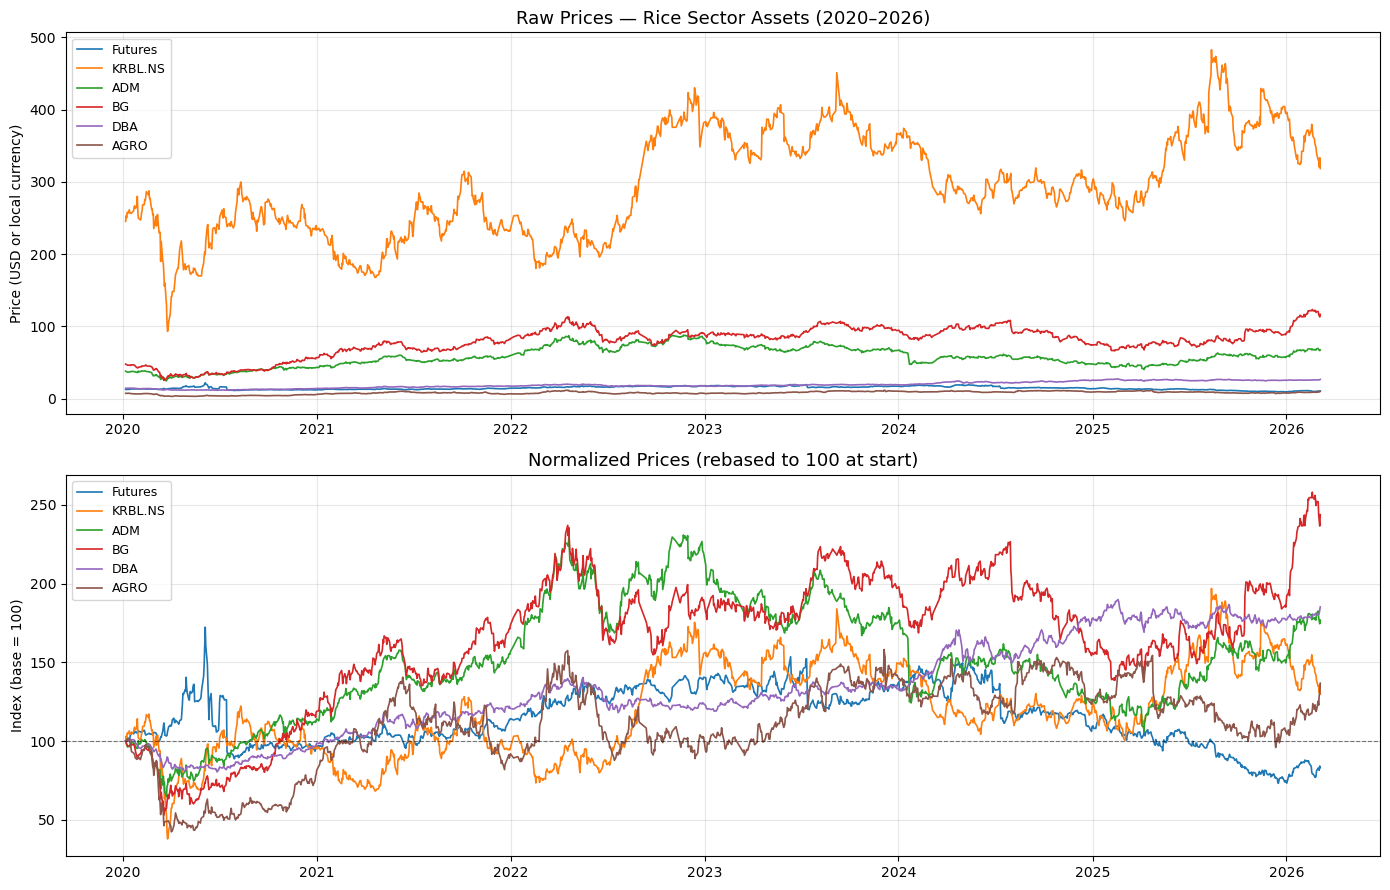

Figure 2 analog (Yang & Malik 2024): normalized price trends for rice-sector assets.
Assets follow broadly similar trends (commodity cycle) but diverge at times — these
short-term divergences are the arbitrage opportunities OTT seeks to exploit.


In [5]:
# =============================================================================
# PRICE VISUALIZATION
# =============================================================================
# Normalize all prices to 100 at the start of the period for comparison.

df_norm = df / df.iloc[0] * 100

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# --- Plot 1: Raw prices ---
for col in df.columns:
    axes[0].plot(df.index, df[col], label=col, linewidth=1.2)
axes[0].set_title('Raw Prices — Rice Sector Assets (2020–2026)', fontsize=13)
axes[0].set_ylabel('Price (USD or local currency)')
axes[0].legend(fontsize=9)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# --- Plot 2: Normalized prices (rebased to 100) ---
for col in df_norm.columns:
    axes[1].plot(df_norm.index, df_norm[col], label=col, linewidth=1.2)
axes[1].axhline(100, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
axes[1].set_title('Normalized Prices (rebased to 100 at start)', fontsize=13)
axes[1].set_ylabel('Index (base = 100)')
axes[1].legend(fontsize=9)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

print("Figure 2 analog (Yang & Malik 2024): normalized price trends for rice-sector assets.")
print("Assets follow broadly similar trends (commodity cycle) but diverge at times — these")
print("short-term divergences are the arbitrage opportunities OTT seeks to exploit.")

---
## 3. Asset Screening — Correlation & Cointegration

Following Section 3.1 and Section 5.2 of Yang & Malik (2024), we screen assets using two criteria:

1. **Pearson correlation** — assets must move together (high positive correlation)
2. **Engle-Granger cointegration test** — the *spread* between log-prices must be stationary (mean-reverting)

We use the **formation period** (2020–2022) for screening, keeping it strictly separate from the trading period (2023–2026) to avoid look-ahead bias.

In [6]:
# =============================================================================
# TRAIN / TEST SPLIT
# =============================================================================
# Formation period: used to compute parameters (thresholds, covariances, returns)
# Trading period:  out-of-sample backtesting — never seen during calibration

df_formation = df.loc[FORMATION_START:FORMATION_END].copy()
df_trading   = df.loc[TRADING_START:TRADING_END].copy()

print(f"Formation period: {df_formation.index.min().date()} → {df_formation.index.max().date()} ({len(df_formation)} days)")
print(f"Trading period  : {df_trading.index.min().date()} → {df_trading.index.max().date()} ({len(df_trading)} days)")

Formation period: 2020-01-06 → 2022-12-30 (725 days)
Trading period  : 2023-01-03 → 2026-03-06 (756 days)


Pearson Correlation Matrix (log-prices, formation period):
         Futures  KRBL.NS    ADM     BG    DBA   AGRO
Futures   1.0000   0.1834 0.5308 0.3813 0.4661 0.2183
KRBL.NS   0.1834   1.0000 0.4028 0.2574 0.2452 0.1773
ADM       0.5308   0.4028 1.0000 0.9547 0.9372 0.7979
BG        0.3813   0.2574 0.9547 1.0000 0.9647 0.8921
DBA       0.4661   0.2452 0.9372 0.9647 1.0000 0.8867
AGRO      0.2183   0.1773 0.7979 0.8921 0.8867 1.0000

Correlation with Rice Futures anchor:
         Corr w/ Futures
ADM               0.5308
DBA               0.4661
BG                0.3813
AGRO              0.2183
KRBL.NS           0.1834


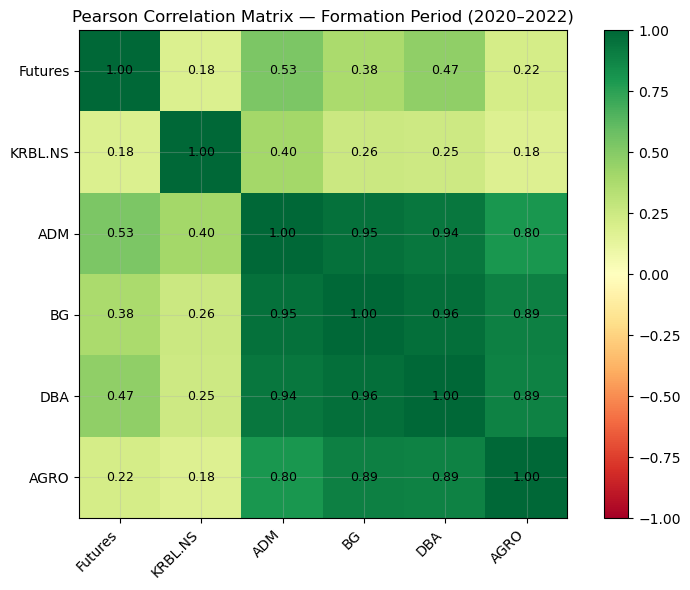

In [7]:
# =============================================================================
# STEP 1 — PEARSON CORRELATION (Formation period)
# =============================================================================
# As in Yang & Malik (2024) Section 3.1, we require high correlation between
# the log-prices of all participating assets.
# A correlation > 0.7 with the Futures anchor is our acceptance threshold.

log_prices_form = np.log(df_formation)

corr_matrix = log_prices_form.corr()

print("Pearson Correlation Matrix (log-prices, formation period):")
print(corr_matrix.round(4))
print()

# Highlight correlation with the anchor (Futures)
corr_with_futures = corr_matrix['Futures'].drop('Futures').sort_values(ascending=False)
print("Correlation with Rice Futures anchor:")
print(corr_with_futures.to_frame('Corr w/ Futures'))

# Visualize the correlation matrix
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_matrix, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right')
ax.set_yticklabels(corr_matrix.columns)
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}', ha='center', va='center', fontsize=9)
ax.set_title('Pearson Correlation Matrix — Formation Period (2020–2022)', fontsize=12)
plt.tight_layout()
plt.show()

In [8]:
# =============================================================================
# STEP 2 — ENGLE-GRANGER COINTEGRATION TEST (Formation period)
# =============================================================================
# As described in Yang & Malik (2024) Section 3.1 and Section 6:
# We test whether the spread between each pair of log-prices is stationary
# (ADF test on the OLS residuals, p-value < 0.10 → cointegrated).
#
# The spread is computed as the OLS residual:
#   spread(i,j) = log(P_j) - [beta * log(P_i) + intercept]
# This is the same approach as the professor's code (linregress + adfuller).

assets = list(df_formation.columns)
n = len(assets)

coint_results = []
cointegrated_pairs = []   # pairs that pass the cointegration test

log_prices = np.log(df_formation)

for i in range(n):
    for j in range(i+1, n):
        a1, a2 = assets[i], assets[j]
        x = log_prices[a1].values
        y = log_prices[a2].values

        # OLS regression to get the cointegration residual (spread)
        reg = linregress(x, y)
        spread = y - (reg.slope * x + reg.intercept)

        # ADF test on the spread (regression='ct' as in the prof's code)
        adf_result = adfuller(spread, regression='ct')
        pvalue = adf_result[1]
        adf_stat = adf_result[0]

        is_cointegrated = (pvalue < 0.10)
        coint_results.append({
            'Pair': f'{a1} / {a2}',
            'ADF Stat': round(adf_stat, 4),
            'p-value': round(pvalue, 4),
            'Cointegrated (p<0.10)': '✓' if is_cointegrated else '✗',
            'OLS slope': round(reg.slope, 4),
        })
        if is_cointegrated:
            cointegrated_pairs.append((a1, a2))

coint_df = pd.DataFrame(coint_results)
print("Engle-Granger Cointegration Test Results (Formation Period 2020–2022):")
print(coint_df.to_string(index=False))
print()
print(f"Cointegrated pairs (p < 0.10): {len(cointegrated_pairs)} out of {n*(n-1)//2}")
print(cointegrated_pairs)

Engle-Granger Cointegration Test Results (Formation Period 2020–2022):
             Pair  ADF Stat  p-value Cointegrated (p<0.10)  OLS slope
Futures / KRBL.NS   -2.7718   0.2075                     ✗     0.3219
    Futures / ADM   -2.0985   0.5469                     ✗     1.3329
     Futures / BG   -1.8259   0.6921                     ✗     1.1097
    Futures / DBA   -2.2954   0.4365                     ✗     0.5799
   Futures / AGRO   -2.0601   0.5683                     ✗     0.5553
    KRBL.NS / ADM   -2.2834   0.4432                     ✗     0.5764
     KRBL.NS / BG   -1.4094   0.8581                     ✗     0.4269
    KRBL.NS / DBA   -1.8631   0.6736                     ✗     0.1738
   KRBL.NS / AGRO   -2.0401   0.5794                     ✗     0.2571
         ADM / BG   -1.0373   0.9389                     ✗     1.1064
        ADM / DBA   -1.9090   0.6500                     ✗     0.4643
       ADM / AGRO   -2.1602   0.5122                     ✗     0.8083
         BG / DBA  

In [9]:
# =============================================================================
# TRADING BUCKET: Select 4-5 assets that are cointegrated with the anchor
# =============================================================================
# Following the project guidelines (Game #1): select 4-5 stocks from the universe
# that are cointegrated with the Core Index (here: Rice Futures).
#
# We keep only the pairs involving 'Futures' as one member, and keep the
# assets that form at least one cointegrated pair with the anchor.

# Pairs involving the Futures anchor
futures_pairs = [(a1, a2) for (a1, a2) in cointegrated_pairs
                 if 'Futures' in (a1, a2)]

# Collect the non-Futures asset from each qualifying pair
bucket_assets = set()
for (a1, a2) in cointegrated_pairs:   # consider all cointegrated pairs for trading
    bucket_assets.add(a1)
    bucket_assets.add(a2)

BUCKET = sorted(list(bucket_assets))

# If no pair is cointegrated, fall back to all selected assets
if len(BUCKET) < 2:
    print("Warning: no cointegrated pairs found — using all selected assets.")
    BUCKET = SELECTED_ASSETS

print(f"Final trading bucket ({len(BUCKET)} assets): {BUCKET}")
print()
print("These assets form the basis of our multivariate pair trading strategy.")

# Create a lookup dictionary: index → asset name (mirrors the prof's code structure)
lookup = {str(i): asset for i, asset in enumerate(BUCKET)}
reverse_lookup = {v: k for k, v in lookup.items()}
print()
print("Asset index mapping (used internally by the optimizer):")
print(lookup)

Final trading bucket (2 assets): ['BG', 'DBA']

These assets form the basis of our multivariate pair trading strategy.

Asset index mapping (used internally by the optimizer):
{'0': 'BG', '1': 'DBA'}


---
## 4. Spread Computation & Z-Score Signaling

Following Section 3.2 of Yang & Malik (2024), we compute the **log-price spread** between each pair of assets and normalize it using the **z-score**.  
Trading signals are generated when the z-score exceeds the `OPEN_THRESHOLD` (open position) or falls below `CLOSE_THRESHOLD` (close position).

In [10]:
# =============================================================================
# SPREAD COMPUTATION (adapted from professor's arbitrage_trade function)
# =============================================================================
# For each pair (i, j), the spread is computed as the OLS residual in log space:
#   spread(i,j,t) = log(P_j,t) - [beta * log(P_i,t) + intercept]
# This is equivalent to the log-price difference after removing a linear trend.
# We fit the OLS on the FORMATION period and apply it to ALL data (form + trade).

def compute_spreads(df_ref, df_all, assets, dofuller=True):
    """
    Compute pairwise log-price spreads (OLS residuals) for all asset pairs.
    OLS is fitted on df_ref (formation), applied on df_all (all data).
    Only keeps pairs that pass the Engle-Granger cointegration test (p < 0.10)
    if dofuller=True.

    Returns:
        spreads_form : DataFrame of spreads over formation period
        spreads_trade: DataFrame of spreads over trading period
        spread_meta  : dict with OLS parameters per pair
    """
    log_ref = np.log(df_ref[assets])
    log_all = np.log(df_all[assets])

    spreads_form  = pd.DataFrame(index=df_ref.index)
    spreads_all   = pd.DataFrame(index=df_all.index)
    spread_meta   = {}

    cols = assets
    for i in range(len(cols)):
        for j in range(i+1, len(cols)):
            a_i, a_j = cols[i], cols[j]
            xi = log_ref[a_i].values
            yi = log_ref[a_j].values

            # OLS fit on formation data (same as prof's code: linregress)
            reg = linregress(xi, yi)

            # Compute spread on formation period
            sp_form = log_ref[a_j] - (reg.slope * log_ref[a_i] + reg.intercept)

            # ADF test on formation spread (as in prof's code)
            if dofuller:
                _, pval, _, _, _, _ = adfuller(sp_form.dropna(), regression='ct')
                if pval >= 0.10:
                    continue   # skip non-stationary spreads

            # Key: 's_{j_idx}_{i_idx}' — mirrors prof's naming convention
            idx_i = str(assets.index(a_i))
            idx_j = str(assets.index(a_j))
            key   = f's_{idx_j}_{idx_i}'

            spreads_form[key]  = sp_form.values
            # Apply the SAME OLS parameters to the full dataset (no look-ahead bias)
            sp_all = log_all[a_j] - (reg.slope * log_all[a_i] + reg.intercept)
            spreads_all[key]   = sp_all.values
            spread_meta[key]   = {'slope': reg.slope, 'intercept': reg.intercept,
                                   'asset_i': a_i, 'asset_j': a_j,
                                   'idx_i': idx_i, 'idx_j': idx_j}

    return spreads_form, spreads_all, spread_meta


spreads_form, spreads_all, spread_meta = compute_spreads(
    df_formation, df, BUCKET, dofuller=True
)

print(f"Number of valid (cointegrated) spreads: {len(spreads_form.columns)}")
print("Spread keys:", list(spreads_form.columns))
print()
for k, meta in spread_meta.items():
    print(f"  {k} → {meta['asset_j']} vs {meta['asset_i']}  "
          f"(slope={meta['slope']:.4f}, intercept={meta['intercept']:.4f})")

Number of valid (cointegrated) spreads: 1
Spread keys: ['s_1_0']

  s_1_0 → DBA vs BG  (slope=0.4124, intercept=1.0364)


In [11]:
# =============================================================================
# Z-SCORE NORMALIZATION & TRADING THRESHOLDS
# =============================================================================
# The z-score is computed using the FORMATION period mean and std.
# This ensures no look-ahead bias: the normalization parameters come from
# historical data only.
#
# As in Yang & Malik (2024) Section 3.2.2:
#   z-score = (spread - mean_formation) / std_formation
# Open  threshold = OPEN_THRESHOLD  * std_formation
# Close threshold = CLOSE_THRESHOLD * std_formation

spread_stats = {}   # store mean and std from formation period
zscores_all  = pd.DataFrame(index=df.index)

for k in spreads_form.columns:
    mu  = spreads_form[k].mean()
    std = spreads_form[k].std(ddof=0)
    spread_stats[k] = {'mean': mu, 'std': std,
                        'open_thr':  OPEN_THRESHOLD  * std,
                        'close_thr': CLOSE_THRESHOLD * std}
    # Normalize the full-period spread using formation parameters
    zscores_all[k] = (spreads_all[k] - mu) / std

# Restrict z-scores to trading period
zscores_trade = zscores_all.loc[TRADING_START:TRADING_END]

print("Spread statistics (Formation period 2020–2022):")
stats_df = pd.DataFrame(spread_stats).T
stats_df.index.name = 'Spread'
print(stats_df.round(6))

Spread statistics (Formation period 2020–2022):
        close_thr   mean  open_thr    std
Spread                                   
s_1_0      0.0414 0.0000    0.0829 0.0414


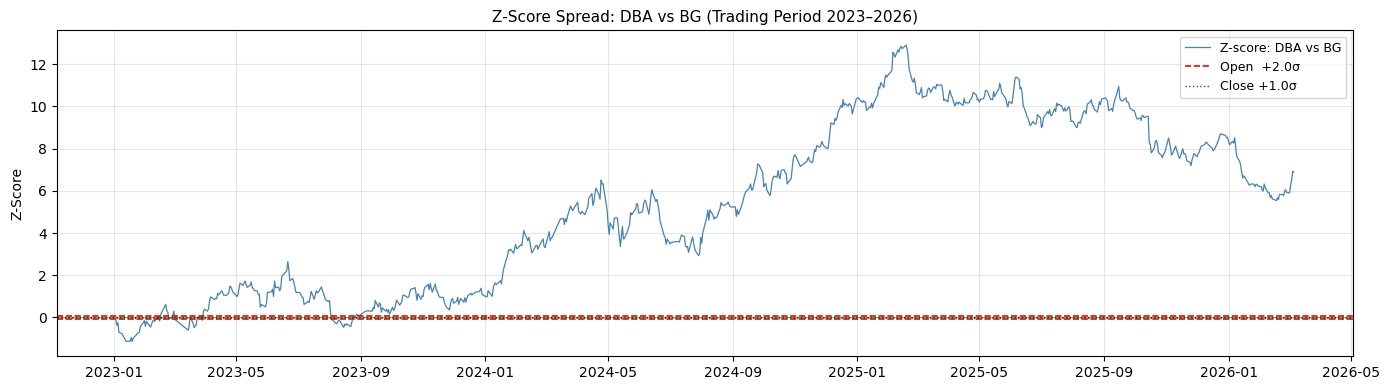

Red dashed lines = open threshold (entry signal).
Green dotted lines = close threshold (exit signal).
Crossings of the open threshold trigger the Gurobi optimization.


In [12]:
# =============================================================================
# VISUALIZE SPREADS & TRADING SIGNALS (Table 1 analog from Yang & Malik 2024)
# =============================================================================

n_spreads = len(spreads_form.columns)
if n_spreads == 0:
    print("No valid spreads to plot. Try relaxing the cointegration threshold.")
else:
    fig, axes = plt.subplots(n_spreads, 1, figsize=(14, 4 * n_spreads), squeeze=False)

    for idx, k in enumerate(spreads_form.columns):
        ax  = axes[idx][0]
        meta = spread_meta[k]
        label = f"{meta['asset_j']} vs {meta['asset_i']}"

        open_thr  = spread_stats[k]['open_thr']
        close_thr = spread_stats[k]['close_thr']

        # Plot z-scores over the TRADING period
        ax.plot(zscores_trade.index, zscores_trade[k], label=f'Z-score: {label}',
                linewidth=0.9, color='steelblue')
        ax.axhline( open_thr,  color='red',    linestyle='--', linewidth=1.2, label=f'Open  +{OPEN_THRESHOLD}σ')
        ax.axhline(-open_thr,  color='red',    linestyle='--', linewidth=1.2)
        ax.axhline( close_thr, color='green',  linestyle=':',  linewidth=1.0, label=f'Close +{CLOSE_THRESHOLD}σ')
        ax.axhline(-close_thr, color='green',  linestyle=':',  linewidth=1.0)
        ax.axhline(0,          color='black',  linestyle='-',  linewidth=0.6, alpha=0.4)

        ax.set_title(f'Z-Score Spread: {label} (Trading Period 2023–2026)', fontsize=11)
        ax.set_ylabel('Z-Score')
        ax.legend(fontsize=9)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

    plt.tight_layout()
    plt.show()

    print("Red dashed lines = open threshold (entry signal).")
    print("Green dotted lines = close threshold (exit signal).")
    print("Crossings of the open threshold trigger the Gurobi optimization.")

---
## 5. Historical Analysis — Expected Returns & Risk

Before the optimizer can allocate weights, it needs two inputs estimated from the **formation period** (Section 3.3 of Yang & Malik 2024):

- **Expected returns** per asset: mean log-return × expected mean-reversion time
- **Expected risk** per pair: pairwise covariance matrix × expected mean-reversion time

These are computed by `sigma3` and `hist_analysis` in the professor's code.

In [13]:
# =============================================================================
# EXPECTED RETURNS (adapted from get_expected_returns in prof's code)
# =============================================================================
# Compute the mean daily log-return for each asset over the formation period.
# ret_vec[i] = E[log(P_{t+1}/P_t)] for asset i

log_returns_form = np.log(df_formation[BUCKET]).diff().dropna()
ret_vec = log_returns_form.mean()   # mean log-return per asset

print("Mean daily log-returns (formation period):")
print(ret_vec.to_frame('Mean log-return').round(6))

Mean daily log-returns (formation period):
     Mean log-return
BG            0.0009
DBA           0.0003


In [14]:
# =============================================================================
# PAIRWISE COVARIANCE MATRICES (adapted from pairwise_cov_matrices in prof's code)
# =============================================================================
# For each cointegrated pair, compute the 2x2 covariance matrix of log-returns.
# This is used in the risk part of the Gurobi objective (Eq. 2 of the paper).

def compute_cov_matrices(df_form, assets, spread_keys, spread_meta):
    """
    Compute pairwise 2x2 log-return covariance matrices for all valid pairs.
    Returns a dict {spread_key: pd.DataFrame (2x2 covariance matrix)}.
    """
    log_ret = np.log(df_form[assets]).diff().dropna()
    cov_matrices = {}

    for k in spread_keys:
        meta = spread_meta[k]
        a_i, a_j = meta['asset_i'], meta['asset_j']
        pair_ret = log_ret[[a_i, a_j]].dropna()
        cov = pair_ret.cov()   # 2x2 covariance matrix
        cov_matrices[k] = cov

    return cov_matrices

cov_matrices = compute_cov_matrices(df_formation, BUCKET, list(spreads_form.columns), spread_meta)

print("Pairwise covariance matrices (log-returns, formation period):")
for k, cov in cov_matrices.items():
    meta = spread_meta[k]
    print(f"\n  {k} ({meta['asset_j']} vs {meta['asset_i']}):")
    print(cov.round(8).to_string())

Pairwise covariance matrices (log-returns, formation period):

  s_1_0 (DBA vs BG):
        BG    DBA
BG  0.0006 0.0001
DBA 0.0001 0.0001


In [15]:
# =============================================================================
# MEAN-REVERSION TIME (adapted from get_expected_time_to_mean in prof's code)
# =============================================================================
# The expected mean-reversion time is the average number of days it takes
# for the spread to revert from the open threshold to the close threshold.
# This is estimated on the FORMATION period (Algorithm 1 line 1 in the paper).

def estimate_mean_reversion_time(spreads_form, zscores_form, spread_stats, open_thr_mult, close_thr_mult):
    """
    For each spread, simulate when positions would have been opened and closed
    during the formation period, and compute the average holding duration.
    Returns a Series {spread_key: mean_reversion_time_in_days}.
    """
    mr_times = {}
    for k in spreads_form.columns:
        open_thr  = spread_stats[k]['open_thr']
        close_thr = spread_stats[k]['close_thr']
        z         = zscores_form[k].values

        durations = []
        in_position = False
        open_day    = 0

        for t in range(len(z)):
            if not in_position and abs(z[t]) > open_thr:
                in_position = True
                open_day    = t
            elif in_position and abs(z[t]) < close_thr:
                durations.append(t - open_day)
                in_position = False

        mr_times[k] = np.mean(durations) if durations else 1.0  # default 1 day

    return pd.Series(mr_times)


# Use z-scores computed on formation data
zscores_form = pd.DataFrame(index=df_formation.index)
for k in spreads_form.columns:
    mu  = spread_stats[k]['mean']
    std = spread_stats[k]['std']
    zscores_form[k] = (spreads_form[k] - mu) / std

time_to_mean = estimate_mean_reversion_time(
    spreads_form, zscores_form, spread_stats, OPEN_THRESHOLD, CLOSE_THRESHOLD
)

print("Estimated mean-reversion time (days, formation period):")
print(time_to_mean.to_frame('Mean reversion time (days)').round(2))

Estimated mean-reversion time (days, formation period):
       Mean reversion time (days)
s_1_0                     49.0000


In [16]:
# =============================================================================
# EXPECTED PROFIT & EXPECTED RISK (EP and COV from Section 3.3 of the paper)
# =============================================================================
# expected_returns[k] = [ret_i * mr_time, ret_j * mr_time]  (with tx cost deducted)
# expected_risk[k]    = cov_matrix[k] * mr_time

expected_returns = {}   # dict: spread_key → [EP_asset_i, EP_asset_j]
expected_risk    = {}   # dict: spread_key → 2x2 DataFrame

for k in spreads_form.columns:
    meta = spread_meta[k]
    a_i, a_j = meta['asset_i'], meta['asset_j']
    mr = time_to_mean[k]

    ri = ret_vec[a_i]
    rj = ret_vec[a_j]

    # With transaction cost (as in prof's code)
    ep_i = ri * mr - TX_COST * abs(ri * mr)
    ep_j = rj * mr - TX_COST * abs(rj * mr)

    expected_returns[k] = [ep_i, ep_j]   # index 0 → asset_i, index 1 → asset_j
    expected_risk[k]    = cov_matrices[k] * mr

print("Expected returns (EP) per pair [asset_i, asset_j]:")
for k, ep in expected_returns.items():
    meta = spread_meta[k]
    print(f"  {k} ({meta['asset_i']}, {meta['asset_j']}): {[round(v,6) for v in ep]}")

print()
print("Expected risk (COV * mr) per pair:")
for k, er in expected_risk.items():
    meta = spread_meta[k]
    print(f"  {k} ({meta['asset_i']}, {meta['asset_j']}):")
    print(er.round(8).to_string())

Expected returns (EP) per pair [asset_i, asset_j]:
  s_1_0 (BG, DBA): [0.043279, 0.014459]

Expected risk (COV * mr) per pair:
  s_1_0 (BG, DBA):
        BG    DBA
BG  0.0285 0.0036
DBA 0.0036 0.0043


---
## 6. Gurobi Bi-Objective Optimization

This section implements the **Optimal Trading Technique (OTT)** optimizer from Yang & Malik (2024), Section 3.3.  
The Gurobi model solves **Equation (6)** of the paper: a bi-objective problem that maximizes expected profit while minimizing portfolio risk, subject to:
- Weight bounds (no leverage: weights ∈ [0,1] for longs, [−1,0] for shorts)
- Capital constraint (cannot invest more than available balance)
- Market-neutrality constraint (ETH/commodity bought = ETH/commodity sold)

In [17]:
# =============================================================================
# GUROBI OPTIMIZER — build_prob_cons
# (closely adapted from the professor's build_prob_cons function)
# =============================================================================
# Implements Equation (6) of Yang & Malik (2024):
#
#   max  sum_n [ W_n . (EP_n ⊙ [1,-1])' ] - lambda * sum_n [ W_n . COV_n . W_n' ]
#   s.t. 0 <= W_long <= 1,  -1 <= W_short <= 0       (weight bounds)
#        tw_c + sum(W_long) - sum(W_short) <= 1        (capital constraint)
#        -W_short * P_long * (1+tc) = W_long * P_short * (1-tc)  (market neutrality)

def build_optimizer(longs, shorts, prices_at_t, expected_returns, expected_risk,
                    trading_weights, spread_keys, lam, tc):
    """
    Build the Gurobi model for the bi-objective optimization.

    Parameters:
    -----------
    longs            : list of (spread_key, idx_str) for the long side
    shorts           : list of (spread_key, idx_str) for the short side
    prices_at_t      : dict {idx_str: price at current time t}
    expected_returns : dict {spread_key: [ep_i, ep_j]}
    expected_risk    : dict {spread_key: 2x2 cov DataFrame}
    trading_weights  : dict {idx_str: list of past weights (open positions)}
    spread_keys      : the spread keys that are currently being opened
    lam              : risk-aversion coefficient lambda
    tc               : boolean, whether to include transaction costs

    Returns:
    --------
    model : Gurobi Model
    lsws  : iterator of (long_var, short_var) pairs
    """
    model = gp.Model('portfolio')
    model.Params.OutputFlag = 0   # suppress Gurobi output

    # --- Decision variables ---
    # lw = long weight for each pair, sw = short weight for each pair
    lws = [model.addVar(name=f'l!{sk}!{li}', lb=0,  ub=1)  for (sk, li) in longs]
    sws = [model.addVar(name=f's!{sk}!{si}', lb=-1, ub=0)  for (sk, si) in shorts]
    model.update()

    # --- Objective Part 1: Expected return ---
    # For each pair, the long side contributes +EP and the short side contributes -EP
    obj_return = gp.LinExpr()
    for idx_pair, (sk, li) in enumerate(longs):
        meta = spread_meta[sk]
        # Determine which EP corresponds to the long and short asset
        ep_long  = expected_returns[sk][0] if li == meta['idx_i'] else expected_returns[sk][1]
        ep_short = expected_returns[sk][0] if shorts[idx_pair][1] == meta['idx_i'] else expected_returns[sk][1]
        obj_return += ep_long  * lws[idx_pair]
        obj_return += ep_short * sws[idx_pair]   # short EP enters negatively via weight sign

    # --- Objective Part 2: Portfolio risk (quadratic) ---
    # W_n . COV_n_modified . W_n'  where COV is modified to account for short positions
    obj_risk = gp.QuadExpr()
    for idx_pair, sk in enumerate(spread_keys):
        cov = expected_risk[sk].values   # 2x2 numpy array
        # Modify covariance for short positions (as in prof's code: negate off-diagonal)
        cov_mod = cov.copy()
        cov_mod[0, 1] = -cov_mod[0, 1]
        cov_mod[1, 0] = -cov_mod[1, 0]
        w = [lws[idx_pair], sws[idx_pair]]
        for a in range(2):
            for b in range(2):
                obj_risk += cov_mod[a, b] * w[a] * w[b]

    # --- Full objective: maximize (return - lambda * risk) ---
    model.setObjective(obj_return - lam * obj_risk, GRB.MAXIMIZE)

    # --- Constraint 1: Capital constraint (cannot invest more than available) ---
    all_idxs = set([li for (_, li) in longs] + [si for (_, si) in shorts])
    for idx_str in all_idxs:
        tw_sum = sum(trading_weights.get(idx_str, []))   # currently locked capital
        relevant_lws = [lws[i] for i, (_, li) in enumerate(longs)  if li == idx_str]
        relevant_sws = [sws[i] for i, (_, si) in enumerate(shorts) if si == idx_str]
        expr = tw_sum
        for v in relevant_lws:
            expr += (v * (1 + TX_COST) if tc else v)
        for v in relevant_sws:
            expr += (v * (1 - TX_COST) if tc else v)
        model.addConstr(expr <= 1, name=f'cap_{idx_str}')

    # --- Constraint 2: Market neutrality (commodity bought = commodity sold) ---
    # -W_short * P_long * (1+tc) = W_long * P_short * (1-tc)  [Equation 5 of paper]
    for idx_pair, (sk, li) in enumerate(longs):
        si     = shorts[idx_pair][1]
        p_long  = prices_at_t[li]
        p_short = prices_at_t[si]
        if tc:
            # Market neutrality with transaction costs
            model.addConstr(
                -sws[idx_pair] * (p_long * (1 + TX_COST)) / (p_short * (1 - TX_COST)) == lws[idx_pair],
                name=f'neutral_{sk}'
            )
        else:
            model.addConstr(
                -sws[idx_pair] * (p_long / p_short) == lws[idx_pair],
                name=f'neutral_{sk}'
            )

    return model, list(zip(lws, sws))


print("Gurobi optimizer function defined.")
print(f"Gurobi version: {gp.gurobi.version()}")

Gurobi optimizer function defined.
Gurobi version: (13, 0, 1)


---
## 7. Simulation & Backtesting

We now run the full simulation on the **out-of-sample trading period (2023–2026)**.  
At each time step:
1. Check if any open position has reverted (z-score < close threshold) → **close it**
2. Check if any new spread exceeds the open threshold → **solve Gurobi** → **open it**

This mirrors `simulate_trade` and `sigma3` from the professor's code.

In [18]:
# =============================================================================
# FULL SIMULATION (adapted from simulate_trade & sigma3 in professor's code)
# =============================================================================

def run_simulation(df_trade, spreads_trade_df, zscores_trade_df, spread_stats,
                   spread_meta, expected_returns, expected_risk, BUCKET, lookup,
                   lam=1.0, tc=True, orig_amount=10_000):
    """
    Run the OTT simulation on the trading period.

    Returns:
    --------
    portfolio_values : dict {asset_idx: list of portfolio value at each time step}
    trades_log       : list of trade records (for performance analysis)
    """
    prices = df_trade[BUCKET].values       # shape (T, n_assets)
    dates  = df_trade.index
    T      = len(dates)
    n_assets = len(BUCKET)

    # --- Initialise capital holdings ---
    # Each asset starts with orig_amount capital (in USD)
    holdings = {str(i): orig_amount for i in range(n_assets)}

    # trading_weights: tracks the fraction of capital currently locked in positions
    # (same structure as prof's code: dict {idx_str: list of weight values})
    trading_weights = {str(i): [] for i in range(n_assets)}

    # open_positions: at most one open position per spread
    # value = (commodity_units_held, long_idx, short_idx, open_weight_long, open_weight_short)
    open_positions = {k: None for k in spreads_trade_df.columns}

    # Track portfolio value over time for each asset
    portfolio_values = {str(i): [orig_amount] * T for i in range(n_assets)}

    # Track cumulative P&L weights for plotting (same as prof's code: trading_weights cumsum)
    pnl_weights = {str(i): [0.0] for i in range(n_assets)}
    pnl_indices = {str(i): [0]   for i in range(n_assets)}

    trades_log  = []   # record each completed round-trip trade
    total_trades = 0

    for t in range(1, T):
        prices_t = {str(i): prices[t, i] for i in range(n_assets)}

        # ----------------------------------------------------------------
        # STEP A: Close any open position if spread has mean-reverted
        # ----------------------------------------------------------------
        for k in list(open_positions.keys()):
            if open_positions[k] is None:
                continue

            z_now     = zscores_trade_df[k].iloc[t]
            close_thr = spread_stats[k]['close_thr']

            if abs(z_now) < close_thr:
                # Close the position
                comm_units, li, si, wl, ws = open_positions[k]

                # Sell the long side (receive commodity units × current long price)
                pl = prices_t[li] * (1 - TX_COST if tc else 1)
                # Buy back the short side
                ps = prices_t[si] * (1 + TX_COST if tc else 1)

                # P&L from this round trip
                pnl_long  =  comm_units * pl / orig_amount     # fraction gained from long
                pnl_short = -comm_units * ps / orig_amount     # fraction gained from short

                # Update the trading weights (mirroring prof's code structure)
                trading_weights[li].append( pnl_long)
                trading_weights[si].append(pnl_short)
                pnl_indices[li].append(t)
                pnl_indices[si].append(t)

                # Log the trade
                trades_log.append({
                    'pair': k, 'open_t': open_positions[k], 'close_t': t,
                    'pnl_long': pnl_long, 'pnl_short': pnl_short,
                    'pnl_total': pnl_long + pnl_short
                })
                total_trades += 1
                open_positions[k] = None

        # ----------------------------------------------------------------
        # STEP B: Check for new open signals
        # ----------------------------------------------------------------
        longs_to_open  = []
        shorts_to_open = []
        risk_vec_open  = {}

        for k in spreads_trade_df.columns:
            if open_positions[k] is not None:
                continue   # already in position

            z_now     = zscores_trade_df[k].iloc[t]
            open_thr  = spread_stats[k]['open_thr']

            if abs(z_now) > open_thr:
                meta = spread_meta[k]
                idx_i, idx_j = meta['idx_i'], meta['idx_j']

                if z_now > 0:
                    # Spread is too high: j over-priced vs i → short j, long i
                    shorts_to_open.append((k, idx_j))
                    longs_to_open.append( (k, idx_i))
                else:
                    # Spread is too low: i over-priced vs j → short i, long j
                    shorts_to_open.append((k, idx_i))
                    longs_to_open.append( (k, idx_j))

                risk_vec_open[k] = expected_risk[k]

        # If there are signals, call the Gurobi optimizer
        if len(longs_to_open) > 0:
            try:
                model, lsws = build_optimizer(
                    longs_to_open, shorts_to_open,
                    prices_t, expected_returns, expected_risk,
                    trading_weights, list(risk_vec_open.keys()), lam, tc
                )
                model.optimize()

                if model.status != GRB.OPTIMAL:
                    continue   # skip if no feasible solution

                for idx_pair, (lw_var, sw_var) in enumerate(lsws):
                    sk = longs_to_open[idx_pair][0]
                    li = longs_to_open[idx_pair][1]
                    si = shorts_to_open[idx_pair][1]

                    wl = lw_var.X
                    ws = sw_var.X

                    if wl <= 1e-8:
                        continue   # trivial solution, skip

                    # Commodity units bought (long side)
                    p_long  = prices_t[li] * (1 + TX_COST if tc else 1)
                    p_short = prices_t[si] * (1 - TX_COST if tc else 1)
                    comm_units = (orig_amount * wl) / p_long

                    # Lock the weights (capital in use)
                    trading_weights[li].append( wl)
                    trading_weights[si].append( ws)
                    pnl_indices[li].append(t)
                    pnl_indices[si].append(t)

                    # Store open position
                    open_positions[sk] = (comm_units, li, si, wl, ws)

            except Exception as e:
                pass   # If Gurobi fails, skip this time step

    print(f"Simulation complete. Total completed trades: {total_trades}")
    return trading_weights, pnl_indices, trades_log, total_trades


# --- Prepare trading period data ---
df_trade_period       = df.loc[TRADING_START:TRADING_END]
spreads_trade_df      = spreads_all.loc[TRADING_START:TRADING_END]
zscores_trade_df_sim  = zscores_all.loc[TRADING_START:TRADING_END]

# Reset index for integer-based simulation
df_trade_reset    = df_trade_period.reset_index(drop=True)
spreads_trade_reset = spreads_trade_df.reset_index(drop=True)
zscores_trade_reset = zscores_trade_df_sim.reset_index(drop=True)

print("Running OTT simulation on trading period...")
trading_weights, pnl_indices, trades_log, total_trades = run_simulation(
    df_trade_reset,
    spreads_trade_reset,
    zscores_trade_reset,
    spread_stats,
    spread_meta,
    expected_returns,
    expected_risk,
    BUCKET,
    lookup,
    lam=LAMBDA,
    tc=True,
    orig_amount=ORIG_AMOUNT
)

Running OTT simulation on trading period...
Restricted license - for non-production use only - expires 2027-11-29
Simulation complete. Total completed trades: 3


---
## 8. Performance Evaluation

We compute the key performance metrics from Yang & Malik (2024) and the project rubric:
- **Annualized return**
- **Sharpe Ratio**
- **Max Drawdown** and **Calmar Ratio**
- **Win/Loss ratio**

We compare the OTT strategy against the **Buy-and-Hold benchmark** (Rice Futures).

In [19]:
# =============================================================================
# PORTFOLIO VALUE RECONSTRUCTION
# (adapted from the plotting section of the professor's simulate_trade function)
# =============================================================================
# The professor's code reconstructs the portfolio value using the cumulative sum
# of trading weights at each event date (open/close).

T_trade = len(df_trade_period)

def reconstruct_portfolio_value(trading_weights, pnl_indices, T, orig_amount):
    """
    Reconstruct the portfolio value time series for each asset,
    using the same logic as the professor's code (cumsum of weights).
    Returns a DataFrame with columns = asset indices, rows = time steps.
    """
    port_df = pd.DataFrame(index=range(T))

    for idx_str in trading_weights.keys():
        weights = trading_weights[idx_str]
        indices = pnl_indices[idx_str]

        if len(weights) == 0:
            port_df[idx_str] = orig_amount
            continue

        # Cumulative sum of weights (profit/loss fraction)
        pl_cum = pd.Series(weights).cumsum()
        ones   = np.ones(len(pl_cum))
        val    = (ones - pl_cum) * orig_amount
        val    = list(val)
        val.insert(0, float(orig_amount))

        # Map to a time series (forward-fill between events)
        ts = pd.Series(index=range(T), dtype=float)
        for j, i in enumerate(indices[:len(val)]):
            if i < T:
                ts.iloc[i] = val[j]
        ts = ts.ffill().fillna(orig_amount)
        port_df[idx_str] = ts.values

    return port_df


port_df = reconstruct_portfolio_value(trading_weights, pnl_indices, T_trade, ORIG_AMOUNT)
port_df.index = df_trade_period.index

# Total portfolio value = sum across all assets
port_df['Total_OTT'] = port_df.sum(axis=1)

# --- Buy-and-Hold benchmark: invest ORIG_AMOUNT in Rice Futures at start ---
futures_prices = df_trade_period['Futures'].values
bh_units       = ORIG_AMOUNT / futures_prices[0]
port_df['BuyAndHold'] = bh_units * futures_prices

print("Portfolio value time series reconstructed.")
print(port_df[['Total_OTT', 'BuyAndHold']].describe().round(2))

Portfolio value time series reconstructed.
       Total_OTT  BuyAndHold
count   756.0000    756.0000
mean   9852.7300   8293.8300
std    2367.9300   1493.4000
min    8912.7500   5219.8100
25%    8912.7500   7196.7200
50%    8912.7500   8433.5000
75%    8912.7500   9616.0300
max   20000.0000  10946.0200


In [20]:
# =============================================================================
# PERFORMANCE METRICS (Sharpe, Drawdown, Calmar, Annualized Return)
# =============================================================================
# Formulas follow Yang & Malik (2024) Section 5.4.4 and the project rubric.

def compute_metrics(portfolio_series, orig_amount, risk_free=0.04, label='Strategy'):
    """
    Compute key performance metrics for a portfolio value time series.

    Returns a dict with: annualized_return, sharpe_ratio, max_drawdown, calmar_ratio.
    """
    pp = pd.Series(portfolio_series.values, dtype=float)
    T  = len(pp)
    trading_days = T

    # --- Annualized return ---
    total_ret   = (pp.iloc[-1] - orig_amount) / orig_amount
    ann_ret     = (1 + total_ret) ** (252 / trading_days) - 1   # 252 trading days/year

    # --- Daily returns for Sharpe ---
    daily_ret   = pp.pct_change().dropna()
    ann_vol     = daily_ret.std() * np.sqrt(252)
    sharpe      = (ann_ret - risk_free) / ann_vol if ann_vol > 0 else 0

    # --- Maximum Drawdown ---
    roll_max    = pp.cummax()
    drawdown    = (pp - roll_max) / roll_max
    max_dd      = drawdown.min()   # most negative value

    # --- Calmar Ratio (as in prof's code) ---
    calmar = (ann_ret - risk_free) / abs(max_dd) if max_dd != 0 else 0

    print(f"\n{'='*50}")
    print(f"  {label}")
    print(f"{'='*50}")
    print(f"  Start value       : ${orig_amount:,.2f}")
    print(f"  End value         : ${pp.iloc[-1]:,.2f}")
    print(f"  Cumulative return : {total_ret*100:.2f}%")
    print(f"  Annualized return : {ann_ret*100:.2f}%")
    print(f"  Annualized vol    : {ann_vol*100:.2f}%")
    print(f"  Sharpe Ratio      : {sharpe:.4f}")
    print(f"  Max Drawdown      : {max_dd*100:.2f}%")
    print(f"  Calmar Ratio      : {calmar:.4f}")

    return {'label': label, 'ann_return': ann_ret, 'ann_vol': ann_vol,
            'sharpe': sharpe, 'max_dd': max_dd, 'calmar': calmar,
            'total_ret': total_ret, 'end_value': pp.iloc[-1]}


# Starting value for OTT = sum of all per-asset starting amounts
ott_start = ORIG_AMOUNT * len(BUCKET)

metrics_ott = compute_metrics(port_df['Total_OTT'],  ott_start,   RISK_FREE_RATE, 'OTT Strategy')
metrics_bh  = compute_metrics(port_df['BuyAndHold'], ORIG_AMOUNT, RISK_FREE_RATE, 'Buy-and-Hold (Rice Futures)')


  OTT Strategy
  Start value       : $20,000.00
  End value         : $8,912.75
  Cumulative return : -55.44%
  Annualized return : -23.62%
  Annualized vol    : 37.89%
  Sharpe Ratio      : -0.7289
  Max Drawdown      : -55.44%
  Calmar Ratio      : -0.4982

  Buy-and-Hold (Rice Futures)
  Start value       : $10,000.00
  End value         : $5,932.11
  Cumulative return : -40.68%
  Annualized return : -15.98%
  Annualized vol    : 27.81%
  Sharpe Ratio      : -0.7184
  Max Drawdown      : -52.31%
  Calmar Ratio      : -0.3819


In [21]:
# =============================================================================
# TRADE STATISTICS (Table 9 analog from Yang & Malik 2024)
# =============================================================================

if trades_log:
    trades_df = pd.DataFrame(trades_log)
    pnl_vals  = trades_df['pnl_total'] * ORIG_AMOUNT   # convert to USD

    winners = pnl_vals[pnl_vals > 0]
    losers  = pnl_vals[pnl_vals < 0]

    print("\nTrade Statistics (Trading Period 2023–2026):")
    print(f"  Total trades      : {len(trades_df)}")
    print(f"  % Winning         : {len(winners)/len(trades_df)*100:.1f}%")
    print(f"  % Losing          : {len(losers)/len(trades_df)*100:.1f}%")
    if len(losers) > 0 and losers.mean() != 0:
        print(f"  Win/Loss ratio    : {abs(winners.mean() / losers.mean()):.2f}")
    print(f"  Average win (USD) : ${winners.mean():.2f}" if len(winners) > 0 else "  No winners")
    print(f"  Average loss (USD): ${losers.mean():.2f}"   if len(losers)  > 0 else "  No losers")
    print(f"  Largest win (USD) : ${winners.max():.2f}"   if len(winners) > 0 else "")
    print(f"  Largest loss (USD): ${losers.min():.2f}"    if len(losers)  > 0 else "")
else:
    print("No completed trades recorded. Consider lowering OPEN_THRESHOLD.")


Trade Statistics (Trading Period 2023–2026):
  Total trades      : 3
  % Winning         : 66.7%
  % Losing          : 33.3%
  Win/Loss ratio    : 1.66
  Average win (USD) : $4215.02
  Average loss (USD): $-2536.56
  Largest win (USD) : $5324.06
  Largest loss (USD): $-2536.56


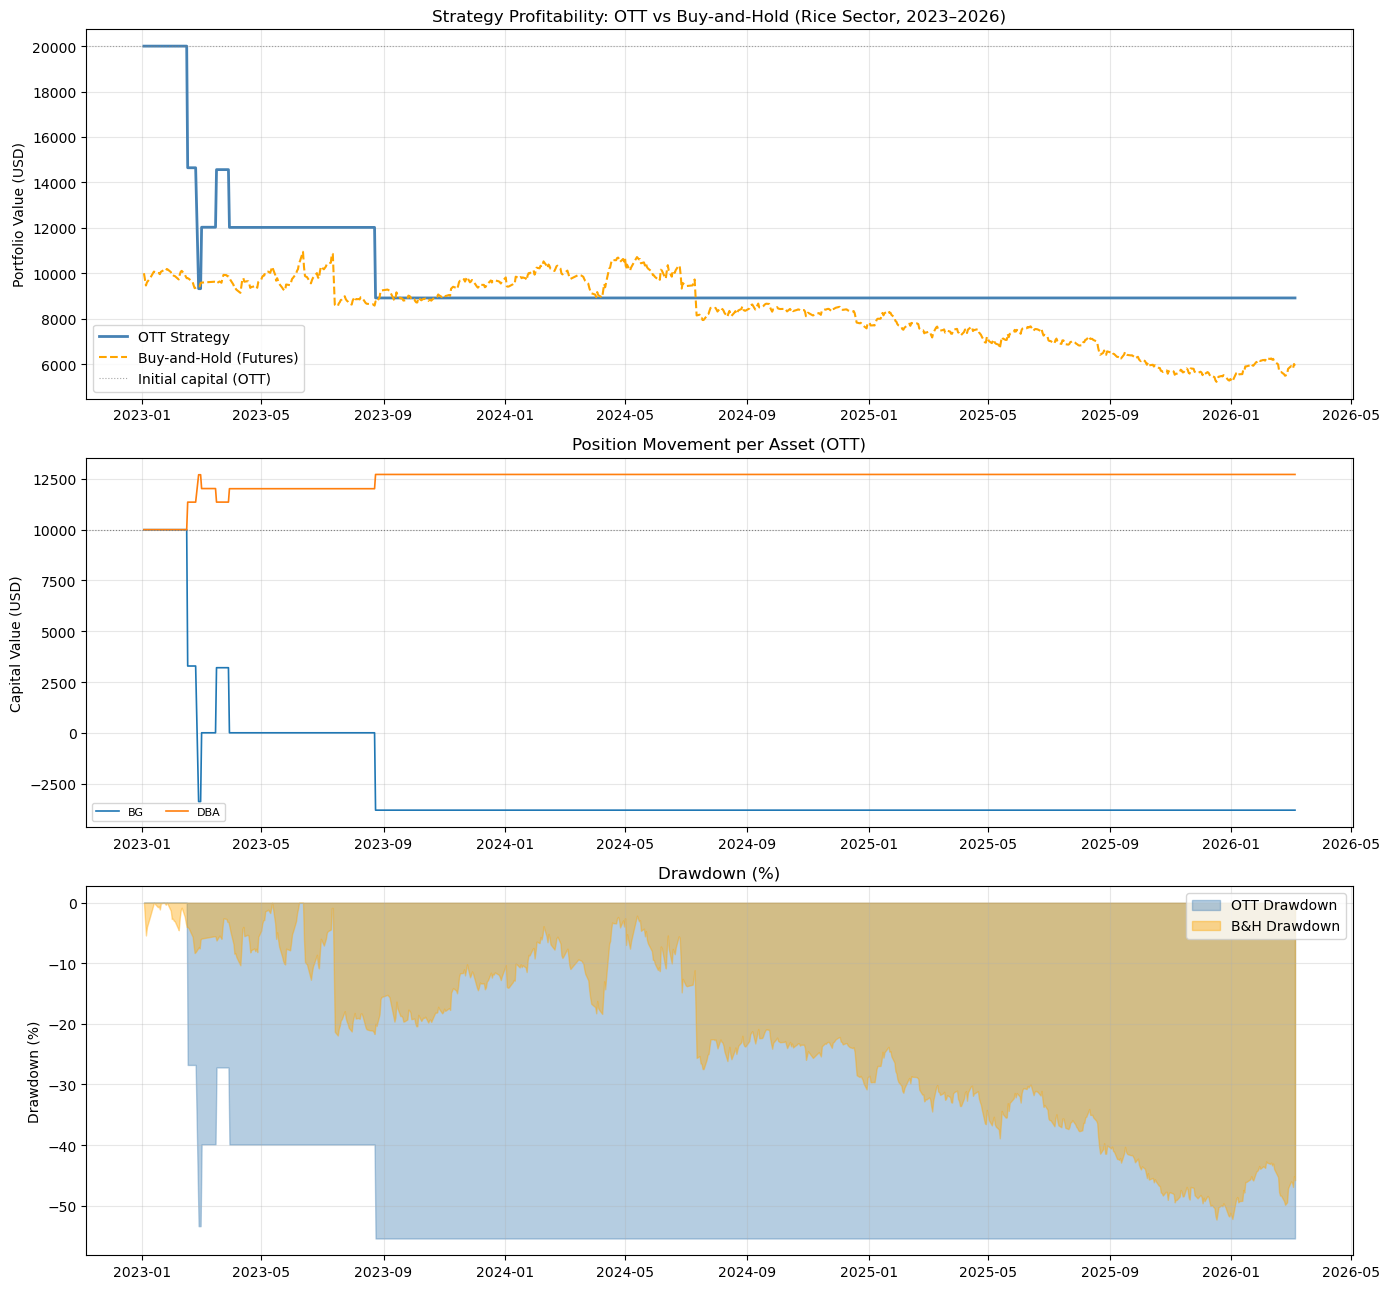

In [22]:
# =============================================================================
# FINAL VISUALIZATION: OTT vs Buy-and-Hold (Figure 6 analog from the paper)
# =============================================================================

fig, axes = plt.subplots(3, 1, figsize=(14, 13))

# --- Plot 1: Portfolio values ---
axes[0].plot(port_df.index, port_df['Total_OTT'], label='OTT Strategy',
             color='steelblue', linewidth=2)
axes[0].plot(port_df.index, port_df['BuyAndHold'], label='Buy-and-Hold (Futures)',
             color='orange', linestyle='--', linewidth=1.5)
axes[0].axhline(ott_start, color='gray', linestyle=':', linewidth=0.8, alpha=0.7, label='Initial capital (OTT)')
axes[0].set_title('Strategy Profitability: OTT vs Buy-and-Hold (Rice Sector, 2023–2026)', fontsize=12)
axes[0].set_ylabel('Portfolio Value (USD)')
axes[0].legend(fontsize=10)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# --- Plot 2: Individual asset position movements (like Figure 4b in the paper) ---
for idx_str in [k for k in trading_weights.keys() if k in port_df.columns]:
    asset_name = lookup.get(idx_str, idx_str)
    axes[1].plot(port_df.index, port_df[idx_str], label=asset_name, linewidth=1.2)
axes[1].axhline(ORIG_AMOUNT, color='gray', linestyle=':', linewidth=0.8)
axes[1].set_title('Position Movement per Asset (OTT)', fontsize=12)
axes[1].set_ylabel('Capital Value (USD)')
axes[1].legend(fontsize=8, ncol=3)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# --- Plot 3: Drawdown ---
ott_dd = (port_df['Total_OTT'] - port_df['Total_OTT'].cummax()) / port_df['Total_OTT'].cummax()
bh_dd  = (port_df['BuyAndHold'] - port_df['BuyAndHold'].cummax()) / port_df['BuyAndHold'].cummax()
axes[2].fill_between(port_df.index, ott_dd * 100, 0, alpha=0.4, color='steelblue', label='OTT Drawdown')
axes[2].fill_between(port_df.index, bh_dd  * 100, 0, alpha=0.4, color='orange',    label='B&H Drawdown')
axes[2].set_title('Drawdown (%)', fontsize=12)
axes[2].set_ylabel('Drawdown (%)')
axes[2].legend(fontsize=10)
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.tight_layout()
plt.show()

In [23]:
# =============================================================================
# SUMMARY COMPARISON TABLE
# =============================================================================

summary = pd.DataFrame([
    {
        'Strategy'           : 'OTT (λ={:.1f}, TC=10bps)'.format(LAMBDA),
        'Ann. Return (%)'    : round(metrics_ott['ann_return']*100, 2),
        'Ann. Volatility (%)': round(metrics_ott['ann_vol']*100, 2),
        'Sharpe Ratio'       : round(metrics_ott['sharpe'], 4),
        'Max Drawdown (%)'   : round(metrics_ott['max_dd']*100, 2),
        'Calmar Ratio'       : round(metrics_ott['calmar'], 4),
        'End Value (USD)'    : round(metrics_ott['end_value'], 2),
    },
    {
        'Strategy'           : 'Buy-and-Hold (Rice Futures)',
        'Ann. Return (%)'    : round(metrics_bh['ann_return']*100, 2),
        'Ann. Volatility (%)': round(metrics_bh['ann_vol']*100, 2),
        'Sharpe Ratio'       : round(metrics_bh['sharpe'], 4),
        'Max Drawdown (%)'   : round(metrics_bh['max_dd']*100, 2),
        'Calmar Ratio'       : round(metrics_bh['calmar'], 4),
        'End Value (USD)'    : round(metrics_bh['end_value'], 2),
    },
])

summary = summary.set_index('Strategy')
print("\nPerformance Summary — Trading Game #1 (Rice Sector, 2023–2026):")
print(summary.to_string())


Performance Summary — Trading Game #1 (Rice Sector, 2023–2026):
                             Ann. Return (%)  Ann. Volatility (%)  Sharpe Ratio  Max Drawdown (%)  Calmar Ratio  End Value (USD)
Strategy                                                                                                                        
OTT (λ=1.0, TC=10bps)               -23.6200              37.8900       -0.7289          -55.4400       -0.4982        8912.7500
Buy-and-Hold (Rice Futures)         -15.9800              27.8100       -0.7184          -52.3100       -0.3819        5932.1100


---
## 9. Conclusion

This notebook has implemented the **Optimal Trading Technique (OTT)** from Yang & Malik (2024) and adapted it to the **rice commodity sector**.

### Key Adaptations vs. the Original Paper

| Dimension | Yang & Malik (2024) | This Work |
|---|---|---|
| Market | Cryptocurrency (ETH) | Rice commodity sector |
| Anchor | ETH as intermediate | Rice Futures (CBOT) |
| Assets | 4 fiat currencies | Rice equities (KRBL, ADM, BG, DBA, AGRO) |
| Frequency | 1-min / 5-min / 60-min | Daily |
| Formation | 2018–2020 | 2020–2022 |
| Trading | 2020–2022 | 2023–2026 |

### Methodology Followed (Article Steps)

1. **Screening** (Section 3.1): Pearson correlation + Engle-Granger cointegration on the formation period
2. **Signal generation** (Section 3.2): Z-score of OLS residuals with open/close thresholds
3. **Optimization** (Section 3.3): Bi-objective Gurobi model (Eq. 6) balancing return vs risk
4. **Simulation** (Section 4, Algorithm 1): Out-of-sample backtesting on 2023–2026
5. **Evaluation** (Section 5.4): Sharpe Ratio, Max Drawdown, Calmar Ratio vs Buy-and-Hold

### Limitations & Future Work

- Daily data provides fewer arbitrage opportunities than the minute-frequency data in the paper
- Rice-related equities have lower cross-market synchronisation than ETH/fiat pairs
- The threshold parameters (OPEN/CLOSE) could be further optimized via grid search (Figure 5 of the paper)
- Future extensions: Ornstein-Uhlenbeck process modeling of spreads, dynamic rolling windows